In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

def find_raw_data_dir(start: Path = Path.cwd()) -> Path:
    for directory in (start, *start.parents):
        for candidate in (directory / 'data' / 'raw', directory / 'data-analytics' / 'data' / 'raw'):
            if candidate.is_dir():
                return candidate
    raise FileNotFoundError('Could not locate data-analytics/data/raw')

RAW_DATA_DIR = find_raw_data_dir()


## 1. Importing & Understanding Data
- Dataframe shape
- head and tail
- dtypes
- describe

In [2]:
df = pd.read_csv(RAW_DATA_DIR / 'Participations.csv')
print(f"Shape: {df.shape}")
display(df.head(10))
display(df.tail(10))

Shape: (28, 9)


,participation_id,programme_id,employee_id,checked_in_at,check_in_method,consent_status,consented_at,attendance_status,created_at
0,PAR-001,PRG-001,EMP-001,2026-06-18T06:07:00Z,qr,granted,2026-06-17T12:00:00Z,attended,2026-06-10T09:00:00Z
1,PAR-002,PRG-001,EMP-002,2026-06-18T06:14:00Z,qr,granted,2026-06-17T12:00:00Z,attended,2026-06-10T09:00:00Z
2,PAR-003,PRG-001,EMP-003,2026-06-18T06:21:00Z,qr,granted,2026-06-17T12:00:00Z,attended,2026-06-10T09:00:00Z
3,PAR-004,PRG-001,EMP-004,2026-06-18T06:28:00Z,qr,granted,2026-06-17T12:00:00Z,attended,2026-06-10T09:00:00Z
4,PAR-005,PRG-001,EMP-005,2026-06-18T06:35:00Z,qr,granted,2026-06-17T12:00:00Z,attended,2026-06-10T09:00:00Z
5,PAR-006,PRG-001,EMP-006,2026-06-18T06:42:00Z,qr,granted,2026-06-17T12:00:00Z,attended,2026-06-10T09:00:00Z
6,PAR-007,PRG-001,EMP-007,2026-06-18T06:49:00Z,qr,granted,2026-06-17T12:00:00Z,attended,2026-06-10T09:00:00Z
7,PAR-008,PRG-001,EMP-008,2026-06-18T06:56:00Z,qr,granted,2026-06-17T12:00:00Z,attended,2026-06-10T09:00:00Z
8,PAR-009,PRG-001,EMP-009,2026-06-18T07:03:00Z,qr,granted,2026-06-17T12:00:00Z,attended,2026-06-10T09:00:00Z
9,PAR-010,PRG-001,EMP-010,2026-06-18T07:10:00Z,qr,granted,2026-06-17T12:00:00Z,attended,2026-06-10T09:00:00Z


,participation_id,programme_id,employee_id,checked_in_at,check_in_method,consent_status,consented_at,attendance_status,created_at
18,PAR-019,PRG-001,EMP-019,2026-06-18T08:13:00Z,qr,granted,2026-06-17T12:00:00Z,attended,2026-06-10T09:00:00Z
19,PAR-020,PRG-001,EMP-020,2026-06-18T08:20:00Z,qr,granted,2026-06-17T12:00:00Z,attended,2026-06-10T09:00:00Z
20,PAR-021,PRG-001,EMP-021,2026-06-18T08:27:00Z,qr,granted,2026-06-17T12:00:00Z,attended,2026-06-10T09:00:00Z
21,PAR-022,PRG-001,EMP-022,2026-06-18T08:34:00Z,qr,granted,2026-06-17T12:00:00Z,attended,2026-06-10T09:00:00Z
22,PAR-023,PRG-001,EMP-023,2026-06-18T08:41:00Z,qr,granted,2026-06-17T12:00:00Z,attended,2026-06-10T09:00:00Z
23,PAR-024,PRG-001,EMP-024,2026-06-18T08:48:00Z,qr,granted,2026-06-17T12:00:00Z,attended,2026-06-10T09:00:00Z
24,PAR-025,PRG-001,EMP-025,NaN,manual,granted,2026-06-17T12:00:00Z,absent,2026-06-10T09:00:00Z
25,PAR-026,PRG-001,EMP-026,NaN,manual,granted,2026-06-17T12:00:00Z,absent,2026-06-10T09:00:00Z
26,PAR-027,PRG-001,EMP-027,NaN,manual,granted,2026-06-17T12:00:00Z,registered,2026-06-10T09:00:00Z
27,PAR-028,PRG-001,EMP-028,NaN,manual,granted,2026-06-17T12:00:00Z,registered,2026-06-10T09:00:00Z


In [3]:
df.columns.tolist()

['participation_id',
 'programme_id',
 'employee_id',
 'checked_in_at',
 'check_in_method',
 'consent_status',
 'consented_at',
 'attendance_status',
 'created_at']

In [4]:
df.dtypes

participation_id     object
programme_id         object
employee_id          object
checked_in_at        object
check_in_method      object
consent_status       object
consented_at         object
attendance_status    object
created_at           object
dtype: object

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28 entries, 0 to 27
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   participation_id   28 non-null     object
 1   programme_id       28 non-null     object
 2   employee_id        28 non-null     object
 3   checked_in_at      24 non-null     object
 4   check_in_method    28 non-null     object
 5   consent_status     28 non-null     object
 6   consented_at       28 non-null     object
 7   attendance_status  28 non-null     object
 8   created_at         28 non-null     object
dtypes: object(9)
memory usage: 2.1+ KB


## 2. Grain integrity checks
- Two separate grain claims to test:
1. "participation_id" which is a unique primary key
2. ("employee_id", "programme_id") is a unique natural key, for example no employee is registered twice for the same programme

In [6]:
#primary key uniqueness check
row_count = len(df)
pk_unique_count = len(df['participation_id'].unique())
print(f"Rows: {row_count} | Unique ParticipationID: {pk_unique_count}")
assert row_count == pk_unique_count, "Primary key uniqueness check failed!"
print("Primary key uniqueness check passed!")

Rows: 28 | Unique ParticipationID: 28
Primary key uniqueness check passed!


In [7]:
#natural key uniqueness check
duplicate_natural_keys = df[df.duplicated(subset=['employee_id', 'programme_id'], keep=False)]
print(f"Duplicate natural keys found: {len(duplicate_natural_keys)}")

if len(duplicate_natural_keys) == 0:
    print("PASS: No employee is registered for the same programme more than once.")
else:
    print("FLAG: Duplicate natural keys found. Please review before this feeds a downstream count metric.")
    display(duplicate_natural_keys.sort_values(['employee_id', 'programme_id']))

Duplicate natural keys found: 0
PASS: No employee is registered for the same programme more than once.


## 3. Missingness Analysis
During data description, 'checked_in_at' is the the only column with nulls. Question is are these nulls structural (expected) or a data quality defect?

Hypothesis: An employee never checked in because they are still 'registered' or ended up 'absent' will correctly have a null checked_in_at.

participation_id     0
programme_id         0
employee_id          0
checked_in_at        4
check_in_method      0
consent_status       0
consented_at         0
attendance_status    0
created_at           0
dtype: int64



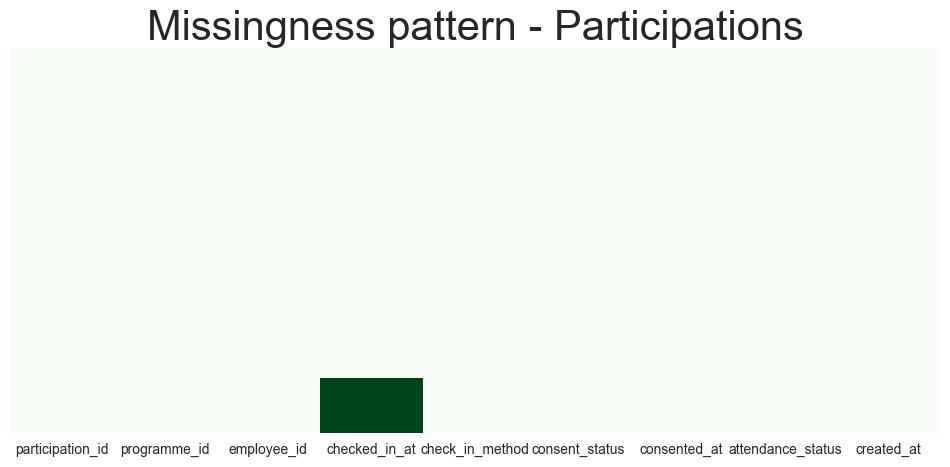

In [8]:
print(df.isna().sum())
print()
plt.figure(figsize=(12, 5))
sns.heatmap(df.isna(), cbar=False, yticklabels=False, cmap='Greens')
plt.title('Missingness pattern - Participations', fontsize=30)
plt.show()

In [9]:
# Proof the null pattern is not random by checking if the nulls are correlated with any other columns
cross_tab = pd.crosstab(df['attendance_status'], df['checked_in_at'].isna(), rownames=['attendance_status'], colnames=['checked_in_at_is_null'])
print(cross_tab)

# Asserting the expected pattern: 'attended' always has a timestamp; 'absent'/'registered' never does.
attended_missing = df.loc[df['attendance_status'] == 'attended', 'checked_in_at'].isna().sum()
not_attended_present = df.loc[df['attendance_status'] != 'attended', 'checked_in_at'].notna().sum()

assert attended_missing == 0, "Error: There are 'attended' records with missing 'checked_in_at' timestamps."
assert not_attended_present == 0, "Error: There are 'absent' or 'registered' records with non-null 'checked_in_at' timestamps."
print("\nPASS: checked_in_at null pattern is consistent with attendance_status values. These are structural nulls, not a pipeline defect.")

checked_in_at_is_null  False  True 
attendance_status                  
absent                     0      2
attended                  24      0
registered                 0      2

PASS: checked_in_at null pattern is consistent with attendance_status values. These are structural nulls, not a pipeline defect.


## 4. Categorical distributions


--- programme_id ---
programme_id
PRG-001    28
Name: count, dtype: int64 

--- check_in_method ---
check_in_method
qr        24
manual     4
Name: count, dtype: int64 

--- consent_status ---
consent_status
granted    28
Name: count, dtype: int64 

--- attendance_status ---
attendance_status
attended      24
absent         2
registered     2
Name: count, dtype: int64 



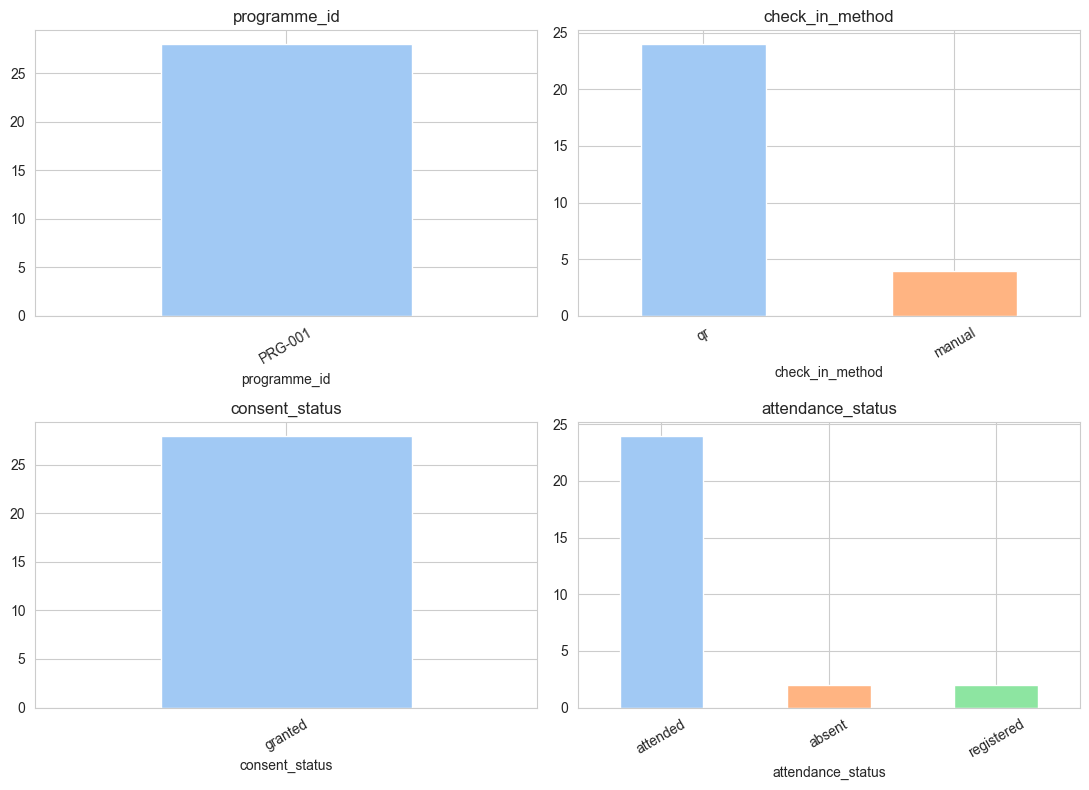

In [10]:
cat_cols = ['programme_id', 'check_in_method', 'consent_status', 'attendance_status']
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, col in zip(axes.flat, cat_cols):
    counts = df[col].value_counts()
    print(f"--- {col} ---")
    print(counts, "\n")
    counts.plot(kind='bar', ax=ax, color=sns.color_palette('pastel'))
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

**Observation to flag:** "consent_status" is "granted" for all 28 rows and "programme_id" is "PRG-001" for all 28 rows. Although it is not a defect, it does mean this sample cannot validate how the table behabves for a declined/revoked consent, or cross multiple programmes.

## 5. Cross-field consistency validation
Rule under test: **`created_at` ≤ `consented_at` ≤ `checked_in_at`** (when `checked_in_at` is present).

In [11]:
for col in ['checked_in_at', 'created_at', 'consented_at']:
    df[col + '_df'] = pd.to_datetime(df[col], utc=True, errors='coerce')
    
# Rule 1: created at should always be before consented_at
violation_1 = df[df['created_at_df'] > df['consented_at_df']]
print(f"created_at > consented_at violations: {len(violation_1)}")

# Rule 2: consented_at <= checked_in_at, only where checked_in_at exists
has_checked_in = df['checked_in_at_df'].notna()
violation_2 = df[has_checked_in & (df['consented_at_df'] > df['checked_in_at_df'])]
print(f"consented_at > checked_in_at violations: {len(violation_2)}")

if len(violation_1) == 0 and len(violation_2) == 0:
    print("PASS: All timestamp (created -> consented -> checked in) rules are satisfied in every row.")
else:
    display(pd.concat([violation_1, violation_2]))    
    

created_at > consented_at violations: 0
consented_at > checked_in_at violations: 0
PASS: All timestamp (created -> consented -> checked in) rules are satisfied in every row.


## 6. Timestamp discipline & sequence anomaly detection
Checking whether a **sequential** field like `checked_in_at` (people checking in one after another at a kiosk/QR scanner) actually behaves sequentially. If check-ins were logged in `participation_id` order, we'd expect a roughly constant gap between consecutive timestamps. A broken gap is a strong signal of either a manual data-entry error or a clock/timezone bug at the source system.

In [12]:
attended = df[df['attendance_status'] == 'attended'].sort_values('participation_id').reset_index(drop=True)
attended['gap_minutes'] = attended['checked_in_at_df'].diff().dt.total_seconds() / 60

display(attended[['participation_id', 'checked_in_at', 'gap_minutes']].head(10))

# Flag any gap that breaks the dominant pattern, including negative gaps (non-monotonic / out-of-order timestamps)
median_gap = attended['gap_minutes'].median()
anomalies = attended[(attended['gap_minutes'] < 0) | (attended['gap_minutes'] > 3 * median_gap)]
print(f"\nMedian gap between check-ins: {median_gap:.1f} minutes")
print(f"Anomalous rows (non-monotonic or outlier gap): {len(anomalies)}")
display(anomalies)

,participation_id,checked_in_at,gap_minutes
0,PAR-001,2026-06-18T06:07:00Z,NaN
1,PAR-002,2026-06-18T06:14:00Z,7.0
2,PAR-003,2026-06-18T06:21:00Z,7.0
3,PAR-004,2026-06-18T06:28:00Z,7.0
4,PAR-005,2026-06-18T06:35:00Z,7.0
5,PAR-006,2026-06-18T06:42:00Z,7.0
6,PAR-007,2026-06-18T06:49:00Z,7.0
7,PAR-008,2026-06-18T06:56:00Z,7.0
8,PAR-009,2026-06-18T07:03:00Z,7.0
9,PAR-010,2026-06-18T07:10:00Z,7.0



Median gap between check-ins: 7.0 minutes
Anomalous rows (non-monotonic or outlier gap): 2


,participation_id,programme_id,employee_id,checked_in_at,check_in_method,consent_status,consented_at,attendance_status,created_at,checked_in_at_df,created_at_df,consented_at_df,gap_minutes
16,PAR-017,PRG-001,EMP-017,2026-06-18T08:59:00Z,qr,granted,2026-06-17T12:00:00Z,attended,2026-06-10T09:00:00Z,2026-06-18 08:59:00+00:00,2026-06-10 09:00:00+00:00,2026-06-17 12:00:00+00:00,67.0
17,PAR-018,PRG-001,EMP-018,2026-06-18T08:06:00Z,qr,granted,2026-06-17T12:00:00Z,attended,2026-06-10T09:00:00Z,2026-06-18 08:06:00+00:00,2026-06-10 09:00:00+00:00,2026-06-17 12:00:00+00:00,-53.0


**Finding:** 'PAR-017' is logged at 08:59, breaking a clean 7 minute cadence that holds for every other row (06:07, 06:14,..., 07:52, then a jump to 08:59, then PAR-018 at 08:06 which is earlier than PAR-017). The gap sequence goes **+67 minutes - 53 minutes,**. The timestamps go backwards between PAR-017 and PAR-018.

This is likely a manual timestamp entry error. An hour typo (`08:59` instead of an expected `~07:59`) that also breaks chronological ordering with the next row. This is worth raising with whoever owns the check-in kiosk/QR ingestion, because:
- It would corrupt any "time-to-check-in" or attendance-latency metric built on this column.
- A single bad row like this rarely fails a null-check or a dtype-check and can only be caught through testing an *ordering* assumption. 

## 7. Participation frequency per employee and per programme

Running this check helps to determine is there is an employee who is registered for an unusually high or low number of programmes once more programme data lands.

In [13]:
freq_by_employee = df['employee_id'].value_counts()
print("Participation count per employee (this file):")
print(freq_by_employee.describe())
print(f"\nMax participations by a single employee: {freq_by_employee.max()}")

q_by_employee = df['programme_id'].value_counts()
print("\nParticipation count per programme:")
print(q_by_employee)

Participation count per employee (this file):
count    28.0
mean      1.0
std       0.0
min       1.0
25%       1.0
50%       1.0
75%       1.0
max       1.0
Name: count, dtype: float64

Max participations by a single employee: 1

Participation count per programme:
programme_id
PRG-001    28
Name: count, dtype: int64


## 8. Duplicate record check (full-row and partial)
This is to check for distinct duplicate rows which is different from the natural-key check from section 2. 

In [14]:
full_dupes = df.duplicated(subset=[c for c in df.columns if not c.endswith('_df')], keep=False)
print(f"Exact duplicates rows: {full_dupes.sum()}")

if full_dupes.sum() == 0:
    print("PASS: No exact duplicate rows found.")
else:
    print("FAIL: Exact duplicate rows found.")
    display(df[full_dupes])

Exact duplicates rows: 0
PASS: No exact duplicate rows found.


## 9. Summary of findings
- **Grain:** `participation_id` is a clean, unique primary key. The natural key `(employee_id, programme_id)` is also unique no double-registrations in this file.
- **Missingness:** `checked_in_at` is null for 4/28 rows, and this is fully explained by `attendance_status` (`absent`/`registered`). These are **structural nulls**, not a pipeline defect.
- **Categorical coverage limitation:** `consent_status` (all `granted`) and `programme_id` (all `PRG-001`) show no variance in this sample declined-consent and multi-programme behaviour are **not yet validated**.
- **Event ordering:** `created_at ≤ consented_at ≤ checked_in_at` holds for every row.
- **Anomaly found:** `PAR-017`'s `checked_in_at` breaks the otherwise-consistent 7-minute check-in cadence and creates a non-monotonic (backwards) timestamp relative to `PAR-018`. Likely a manual timestamp entry error, flagged for follow-up, not silently corrected.
- **Duplicates:** none found, at either the full-row or natural-key level.
- **Relationship model limitation:** this table links **Employees ↔ Programmes** only. There is no `screening_id` / `service_id` column, so its connection to `Risk_Assessments` or `Measurements` is indirect and **cannot be verified without a `Programmes` reference table**, which was not available for this analysis.

## 10. Recommended next steps

1. Request or locate a `Programmes` table (or equivalent) to establish the `programme_id → screening_id/service_id` mapping, this is the missing link needed to answer the original question about how participation connects to screenings and services.
2. Raise the `PAR-017` timestamp anomaly with the team that owns the check-in ingestion source.
3. Once more programme data is available (more than one `programme_id`), re-run Sections 4 and 7, the single-programme sample here limits what those checks can currently tell us.
4. Extend consent-lifecycle validation once records with `declined`/`revoked` consent status exist in the data, since none were present here to test against.